1. Análise explorátoria dos modelos estatísticos a fim de verificar se há extrema sazonalidade ou não

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


df = pd.read_parquet("/Users/adeleborba/Desktop/dengue-jaboatao/data/processed/dengue_jaboatao_2018_2025_processed.parquet")

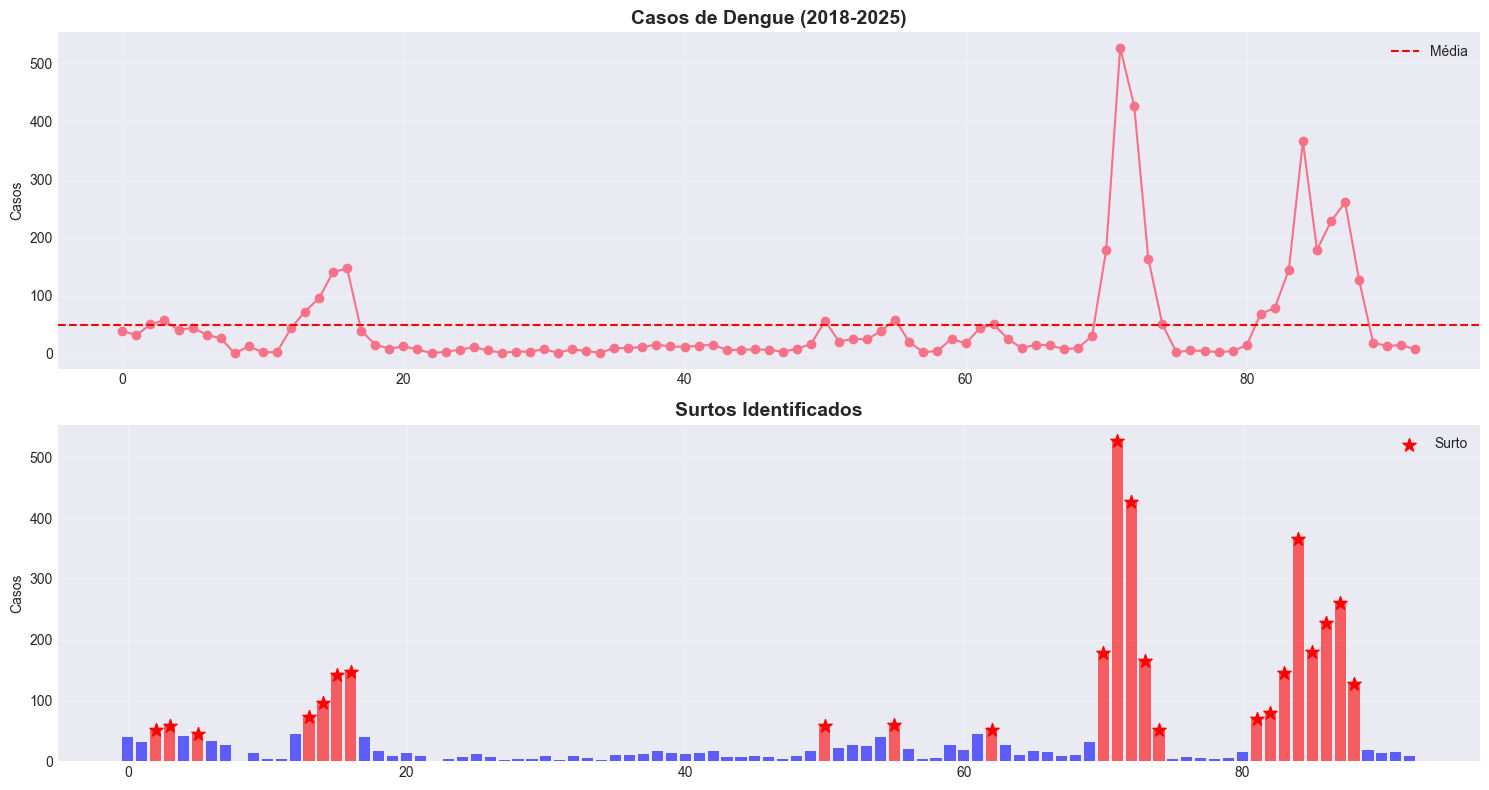

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(df.index, df['casos'], marker='o')
axes[0].axhline(df['casos'].mean(), color='red', linestyle='--', label='Média')
axes[0].set_title('Casos de Dengue (2018-2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Casos')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

surtos_idx = df[df['surto'] == 1].index
axes[1].bar(df.index, df['casos'], color=['red' if s==1 else 'blue' for s in df['surto']], alpha=0.6)
axes[1].scatter(surtos_idx, df.loc[surtos_idx, 'casos'], color='red', s=100, marker='*', label='Surto', zorder=5)
axes[1].set_title('Surtos Identificados', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Casos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

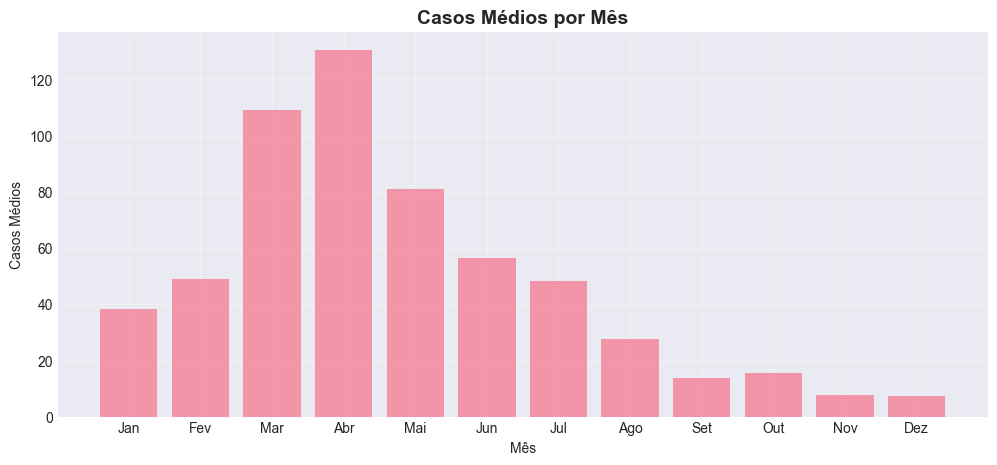


🔍 Razão máx/mín: 17.40x
sazonalidade forte → Usar SARIMA


In [3]:
casos_mes = df.groupby('mes')['casos'].mean()

plt.figure(figsize=(12, 5))
plt.bar(casos_mes.index, casos_mes.values, alpha=0.7)
plt.title('Casos Médios por Mês', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Casos Médios')
plt.xticks(range(1,13), ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
plt.grid(True, alpha=0.3)
plt.show()

# decisão ARIMA vs SARIMA
razao = casos_mes.max() / casos_mes.min()
print(f"\n🔍 Razão máx/mín: {razao:.2f}x")
if razao > 2:
    print("sazonalidade forte → Usar SARIMA")
else:
    print("sazonalidade fraca → ARIMA é suficiente")

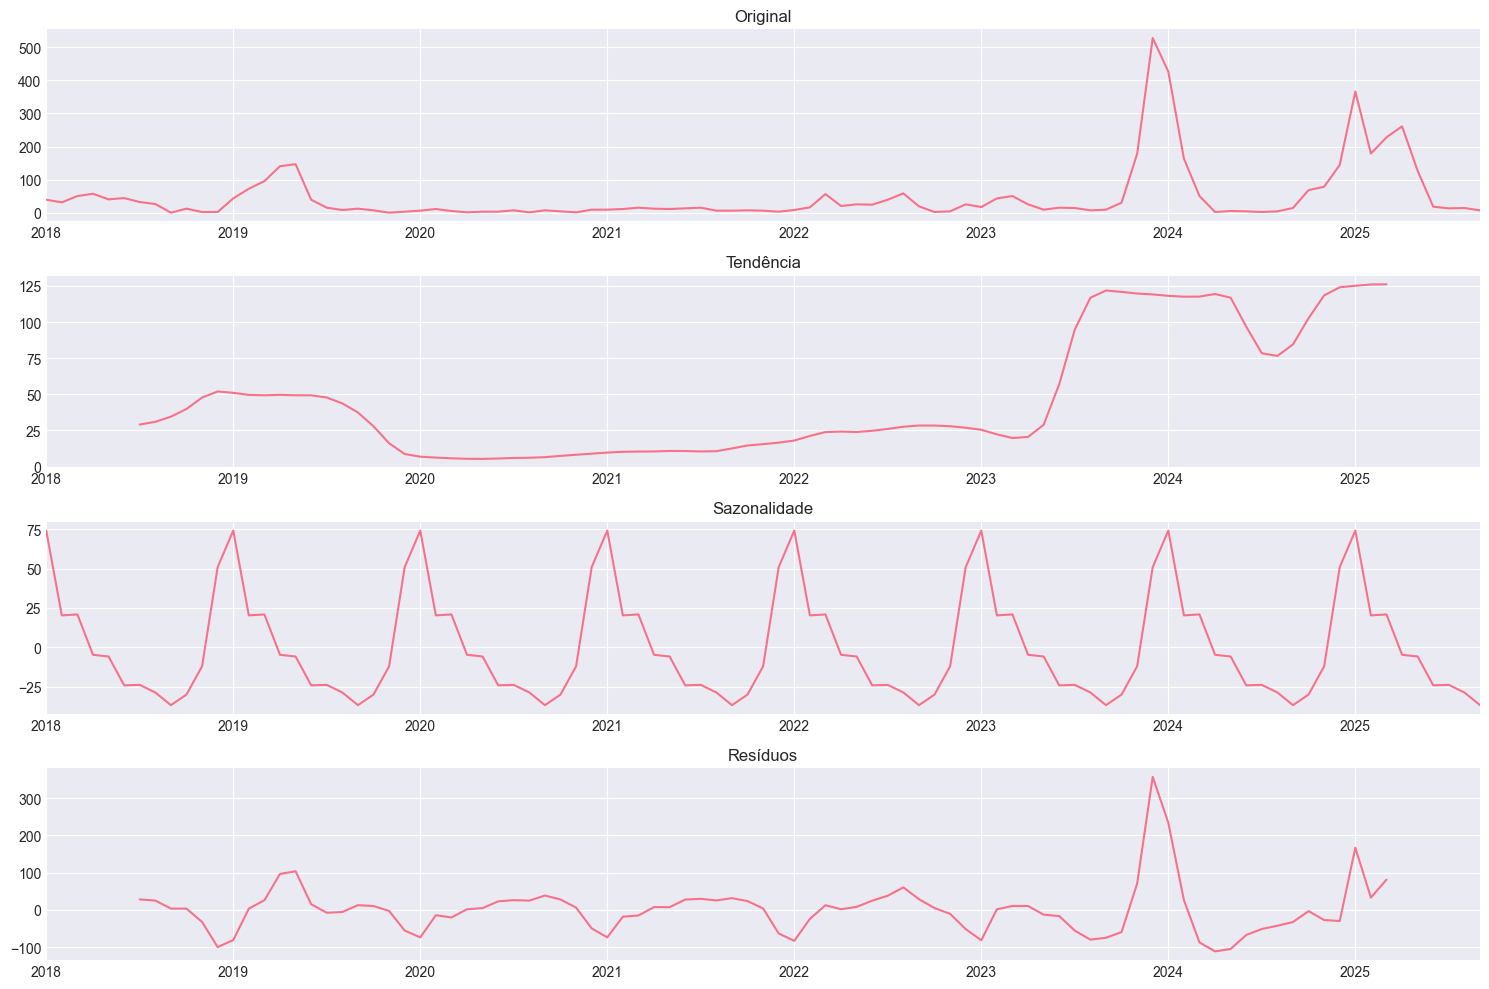

In [4]:
ts = df.set_index(pd.date_range(start='2018-01', periods=len(df), freq='MS'))['casos']
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
decomp.observed.plot(ax=axes[0], title='Original')
decomp.trend.plot(ax=axes[1], title='Tendência')
decomp.seasonal.plot(ax=axes[2], title='Sazonalidade')
decomp.resid.plot(ax=axes[3], title='Resíduos')
plt.tight_layout()
plt.show()

In [ ]:
resultado = adfuller(ts.dropna())
print("\nTESTE ADF (Estacionariedade):")
print(f"p-value: {resultado[1]:.4f}")

if resultado[1] < 0.05:
    print("Série É ESTACIONÁRIA")
else:
    print("Série NÃO É ESTACIONÁRIA → Precisa diferenciação")


📊 TESTE ADF (Estacionariedade):
p-value: 0.0000
Série É ESTACIONÁRIA


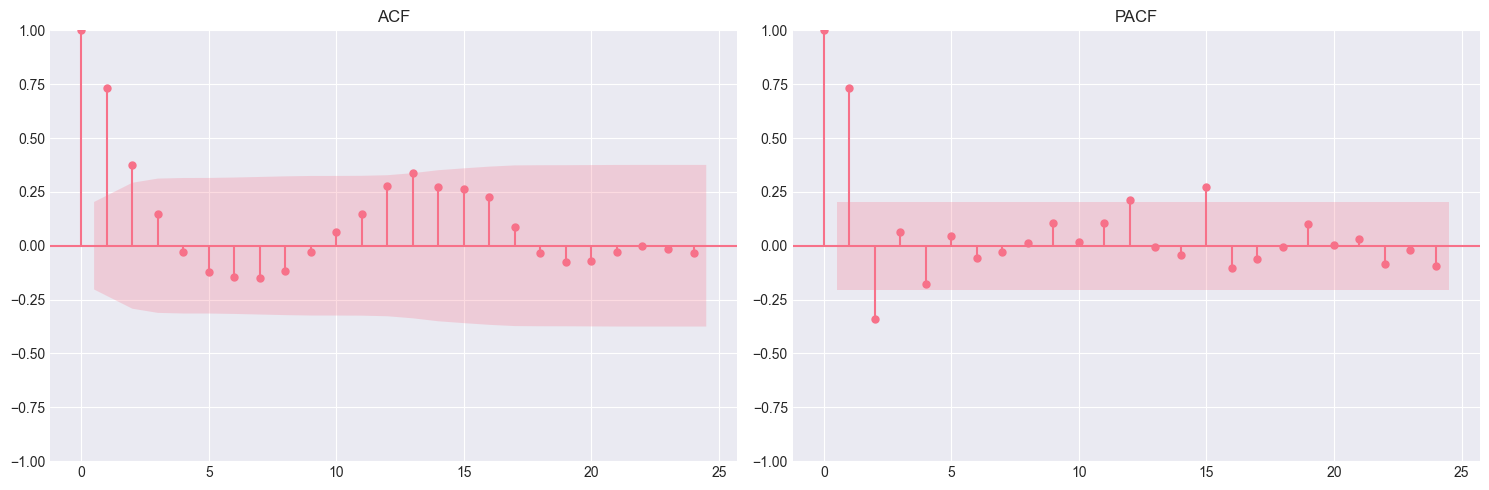

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(ts.dropna(), lags=24, ax=axes[0])
plot_pacf(ts.dropna(), lags=24, ax=axes[1])
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("RECOMENDAÇÕES PARA MODELAGEM")
print("="*60)

tem_sazonalidade = (casos_mes.max() / casos_mes.min()) > 2
balanceado = 0.3 <= df['surto'].mean() <= 0.7

if tem_sazonalidade:
    print("SARIMA")
else:
    print("ARIMA")




RECOMENDAÇÕES PARA MODELAGEM
1. MODELO ESTATÍSTICO: SARIMA
2. CLASSIFICAÇÃO: Classes desbalanceadas (24.7% surto) → Use F1/AUC
3. LSTM: Multitarefa (regressão + classificação)
